# Submission Akhir BMLP - Clustering

**Nama:** Muhammad Azri Fatih Susanto

Notebook ini melakukan clustering (unsupervised learning) pada dataset `dataset_clustering_project` (modifikasi dari *Bank Transaction Dataset for Fraud Detection*) untuk menghasilkan label/kelas yang selanjutnya dipakai pada notebook klasifikasi.

## 1. Import Library

In [1]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer
import joblib

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Memuat Dataset

In [2]:
# Load data
# Sesuaikan nama file dengan dataset yang sudah Anda unduh dari Google Drive
# dan letakkan di dalam folder data/
df = pd.read_csv("data/bank_transactions_data_edited.csv")

## 3. Exploratory Data Analysis (Basic)

In [3]:
# Tampilkan 5 baris pertama dengan function head.
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39


In [4]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   TransactionDate          2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [5]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe
df.describe(include="all")

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
count,2508,2516,2511.000000,2509,2507,2507,2507,2517,2514,2510,2519.000000,2514,2511.000000,2516.000000,2510.000000,2513
unique,2484,495,NaN,2485,2,43,681,591,100,3,NaN,4,NaN,NaN,NaN,360
top,TX000592,AC00363,NaN,2023-10-20 17:53:13,Debit,Fort Worth,D000315,200.136.146.93,M026,Branch,NaN,Student,NaN,NaN,NaN,2024-11-04 08:09:17
freq,2,12,NaN,2,1942,71,9,12,46,868,NaN,657,NaN,NaN,NaN,18
mean,NaN,NaN,297.656468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.678444,NaN,119.422939,1.121622,5113.438124,NaN
std,NaN,NaN,292.230367,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.837359,NaN,70.078513,0.594469,3897.975861,NaN
min,NaN,NaN,0.260000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,10.000000,1.000000,101.250000,NaN
25%,NaN,NaN,81.310000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,63.000000,1.000000,1504.727500,NaN
50%,NaN,NaN,211.360000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.000000,NaN,112.000000,1.000000,4734.110000,NaN
75%,NaN,NaN,413.105000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.000000,NaN,161.000000,1.000000,7672.687500,NaN


### Penilaian (Opsional) - Skilled 1

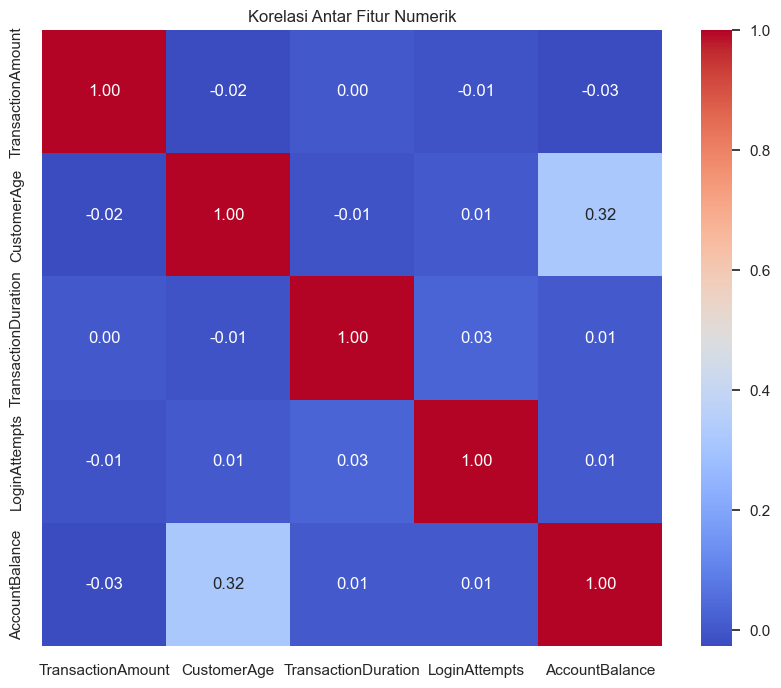

In [6]:
# Menampilkan korelasi antar fitur (Opsional Skilled 1)
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Korelasi Antar Fitur Numerik")
plt.show()

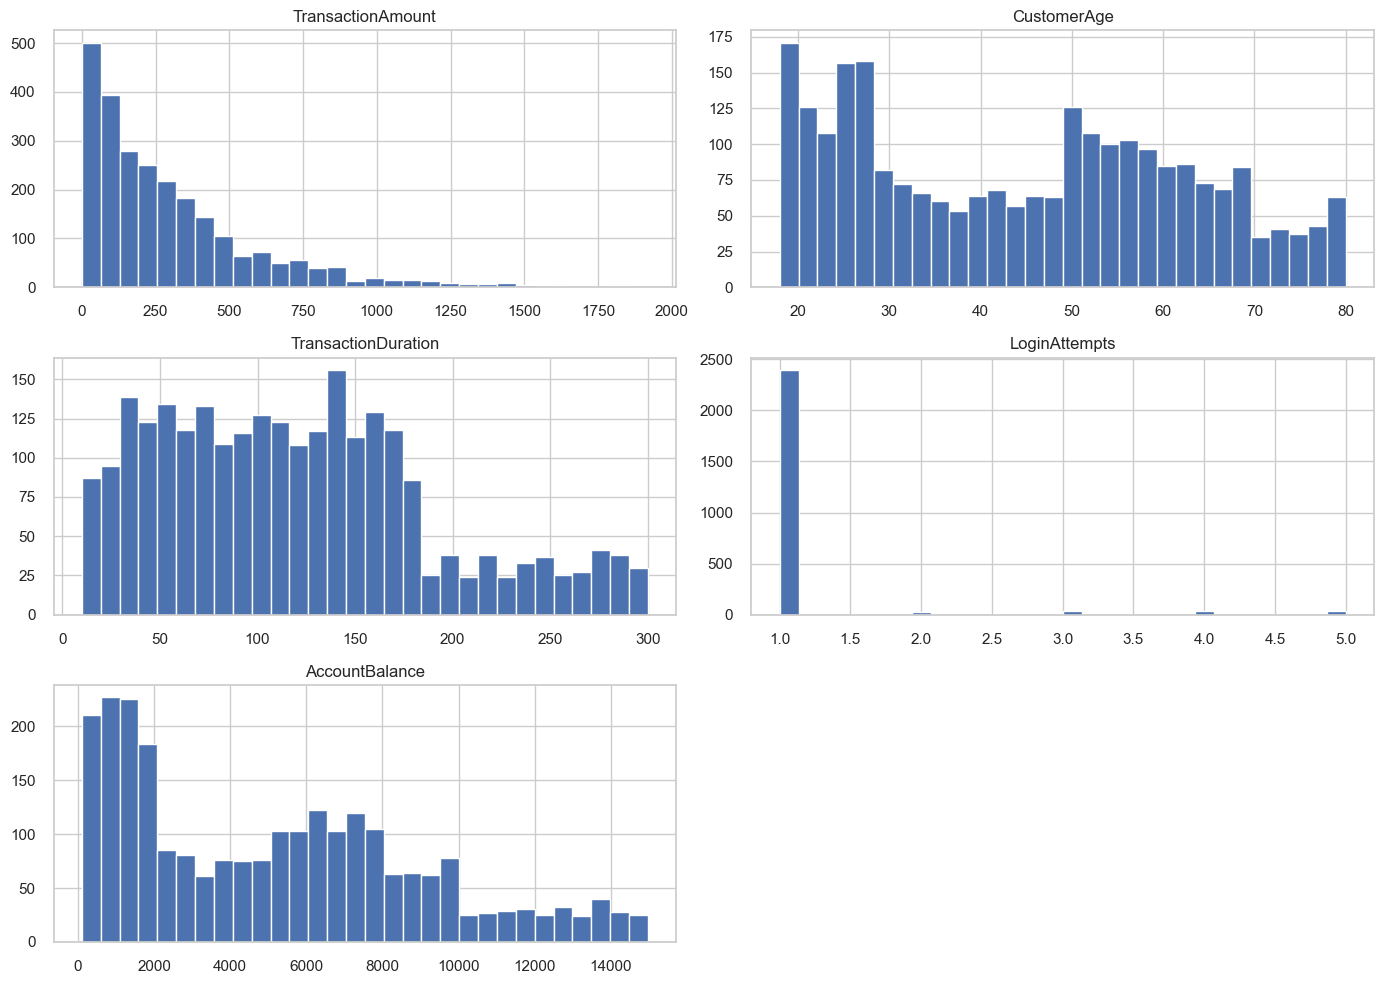

In [7]:
# Menampilkan histogram untuk semua kolom numerik (Opsional Skilled 1)
df.hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

### Penilaian (Opsional) - Advanced 1

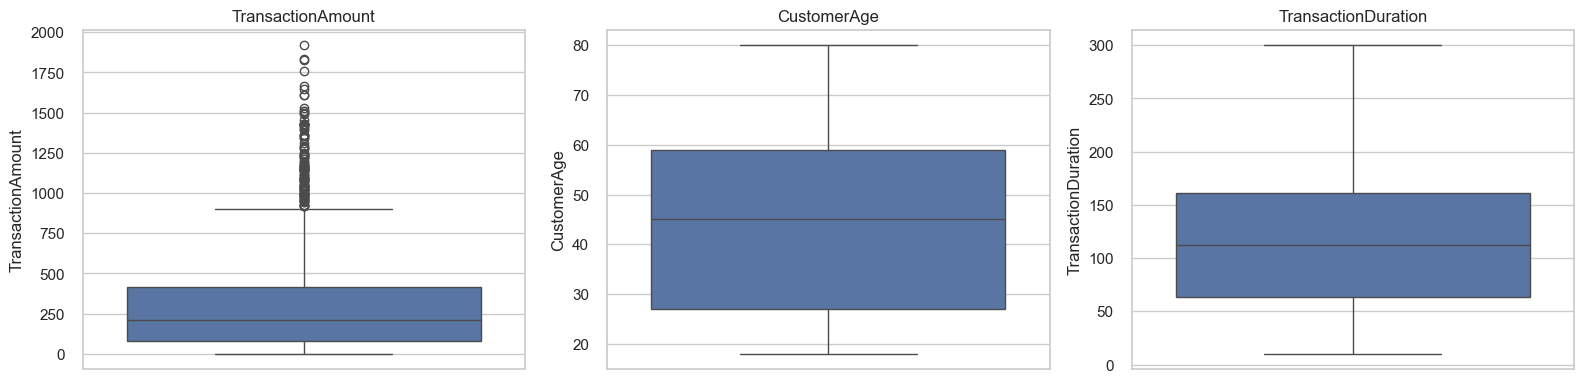

In [8]:
# Visualisasi yang lebih informatif (Opsional Advanced 1)
num_cols = df.select_dtypes(include=np.number).columns
fig, axes = plt.subplots(1, min(3, len(num_cols)), figsize=(16, 4))
for ax, col in zip(np.atleast_1d(axes), num_cols[:3]):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [9]:
# Mengecek dataset menggunakan isnull().sum()
df.isnull().sum()

TransactionID              29
AccountID                  21
TransactionAmount          26
TransactionDate            28
TransactionType            30
Location                   30
DeviceID                   30
IP Address                 20
MerchantID                 23
Channel                    27
CustomerAge                18
CustomerOccupation         23
TransactionDuration        26
LoginAttempts              21
AccountBalance             27
PreviousTransactionDate    24
dtype: int64

In [10]:
# Mengecek dataset menggunakan duplicated().sum()
df.duplicated().sum()

np.int64(21)

In [11]:
# Menangani data yang hilang.
df = df.dropna()

In [12]:
# Menghapus data duplikat.
df = df.drop_duplicates()

In [13]:
# Melakukan drop pada kolom yang memiliki keterangan Date, id, dan IP Address
cols_to_drop = [col for col in df.columns
                if ("date" in col.lower()) or ("id" in col.lower()) or ("ip" in col.lower())]
df = df.drop(columns=cols_to_drop)
cols_to_drop

['TransactionID',
 'AccountID',
 'TransactionDate',
 'DeviceID',
 'IP Address',
 'MerchantID',
 'PreviousTransactionDate']

In [14]:
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal.
cat_cols = df.select_dtypes(include="object").columns
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [15]:
# Last checking gunakan columns.tolist() untuk checking seluruh fitur yang ada.
df.columns.tolist()

['TransactionAmount',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance']

In [16]:
# Melakukan Handling Outlier Data menggunakan metode drop.
num_cols = [c for c in df.select_dtypes(include=np.number).columns if c not in cat_cols]
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
mask = ~((df[num_cols] < (Q1 - 1.5 * IQR)) | (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
df = df[mask].reset_index(drop=True)

In [17]:
# Melakukan feature scaling menggunakan StandardScaler() untuk fitur numerik.
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

In [18]:
# Melakukan binning data berdasarkan kondisi rentang nilai pada fitur numerik,
# Sesuaikan nama kolom dengan fitur numerik yang relevan pada dataset Anda
binning_col = num_cols[0]
df[f"{binning_col}_bin"] = pd.qcut(df[binning_col], q=4,
                                    labels=["Rendah", "Sedang", "Tinggi", "Sangat Tinggi"])

In [19]:
# Gunakan describe untuk memastikan proses clustering menggunakan dataset hasil preprocessing
df_scaled.describe()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
count,1.945000e+03,1945.000000,1945.000000,1945.000000,1.945000e+03,1945.000000,1.945000e+03,1945.0,1.945000e+03
mean,-8.402305e-17,0.771722,21.299743,0.977378,-1.269479e-16,1.503342,2.557223e-17,0.0,-6.027740e-17
std,1.000257e+00,0.419830,12.329250,0.804119,1.000257e+00,1.135888,1.000257e+00,0.0,1.000257e+00
min,-1.175271e+00,0.000000,0.000000,0.000000,-1.504776e+00,0.000000,-1.547483e+00,0.0,-1.279678e+00
25%,-8.149648e-01,1.000000,11.000000,0.000000,-9.974163e-01,0.000000,-7.965883e-01,0.0,-9.247374e-01
50%,-2.617251e-01,1.000000,21.000000,1.000000,1.730327e-02,1.000000,-1.165330e-01,0.0,-1.042490e-01
75%,5.389562e-01,1.000000,32.000000,2.000000,8.065296e-01,3.000000,6.060257e-01,0.0,6.551666e-01
max,2.960651e+00,1.000000,42.000000,2.000000,1.990369e+00,3.000000,2.561185e+00,0.0,2.528623e+00


## 5. Pembangunan Model Clustering (Basic)

/Users/muhammadazrifatihahsusanto/Documents/Codingan/Dicoding/machine_learning/BMLP_Muhammad_Azri_Fatih_Susanto/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/muhammadazrifatihahsusanto/Documents/Codingan/Dicoding/machine_learning/BMLP_Muhammad_Azri_Fatih_Susanto/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/muhammadazrifatihahsusanto/Documents/Codingan/Dicoding/machine_learning/BMLP_Muhammad_Azri_Fatih_Susanto/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/muhammadazrifatihahsusanto/Documents/Codingan/Dicoding/machine_learning/BMLP_Muhammad_Azri_Fatih_Susanto/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight

/Users/muhammadazrifatihahsusanto/Documents/Codingan/Dicoding/machine_learning/BMLP_Muhammad_Azri_Fatih_Susanto/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/muhammadazrifatihahsusanto/Documents/Codingan/Dicoding/machine_learning/BMLP_Muhammad_Azri_Fatih_Susanto/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/muhammadazrifatihahsusanto/Documents/Codingan/Dicoding/machine_learning/BMLP_Muhammad_Azri_Fatih_Susanto/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/muhammadazrifatihahsusanto/Documents/Codingan/Dicoding/machine_learning/BMLP_Muhammad_Azri_Fatih_Susanto/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/muhammadazrifatihahsusanto/D

/Users/muhammadazrifatihahsusanto/Documents/Codingan/Dicoding/machine_learning/BMLP_Muhammad_Azri_Fatih_Susanto/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/muhammadazrifatihahsusanto/Documents/Codingan/Dicoding/machine_learning/BMLP_Muhammad_Azri_Fatih_Susanto/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/muhammadazrifatihahsusanto/Documents/Codingan/Dicoding/machine_learning/BMLP_Muhammad_Azri_Fatih_Susanto/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/muhammadazrifatihahsusanto/Documents/Codingan/Dicoding/machine_learning/BMLP_Muhammad_Azri_Fatih_Susanto/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/muhammadazrifatihahsusanto/D

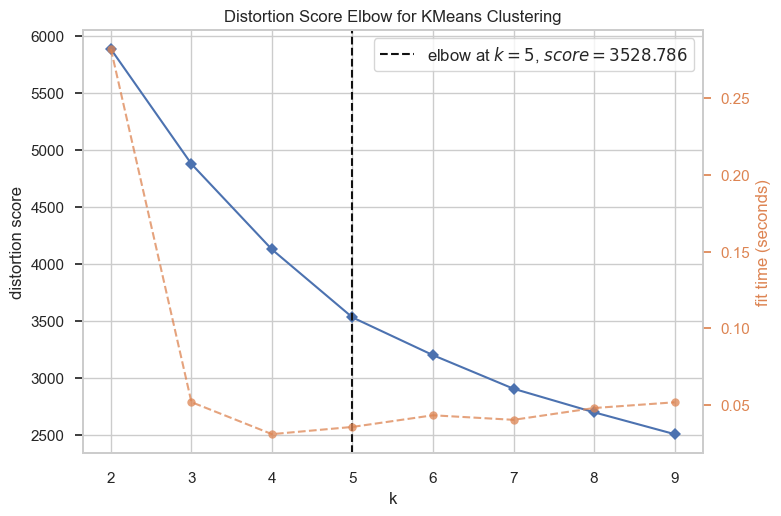

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [20]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()
X = df_scaled[num_cols]
visualizer = KElbowVisualizer(KMeans(random_state=42, n_init=10), k=(2, 10))
visualizer.fit(X)
visualizer.show()

In [21]:
# Menggunakan algoritma K-Means Clustering
n_clusters = visualizer.elbow_value_ or 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

/Users/muhammadazrifatihahsusanto/Documents/Codingan/Dicoding/machine_learning/BMLP_Muhammad_Azri_Fatih_Susanto/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/muhammadazrifatihahsusanto/Documents/Codingan/Dicoding/machine_learning/BMLP_Muhammad_Azri_Fatih_Susanto/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/muhammadazrifatihahsusanto/Documents/Codingan/Dicoding/machine_learning/BMLP_Muhammad_Azri_Fatih_Susanto/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/muhammadazrifatihahsusanto/Documents/Codingan/Dicoding/machine_learning/BMLP_Muhammad_Azri_Fatih_Susanto/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight

In [22]:
# Menyimpan model menggunakan joblib
joblib.dump(kmeans, "model_clustering.h5")

['model_clustering.h5']

In [23]:
# Menghitung dan menampilkan nilai Silhouette Score.
score = silhouette_score(X, cluster_labels)
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.2517


/Users/muhammadazrifatihahsusanto/Documents/Codingan/Dicoding/machine_learning/BMLP_Muhammad_Azri_Fatih_Susanto/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/muhammadazrifatihahsusanto/Documents/Codingan/Dicoding/machine_learning/BMLP_Muhammad_Azri_Fatih_Susanto/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/muhammadazrifatihahsusanto/Documents/Codingan/Dicoding/machine_learning/BMLP_Muhammad_Azri_Fatih_Susanto/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


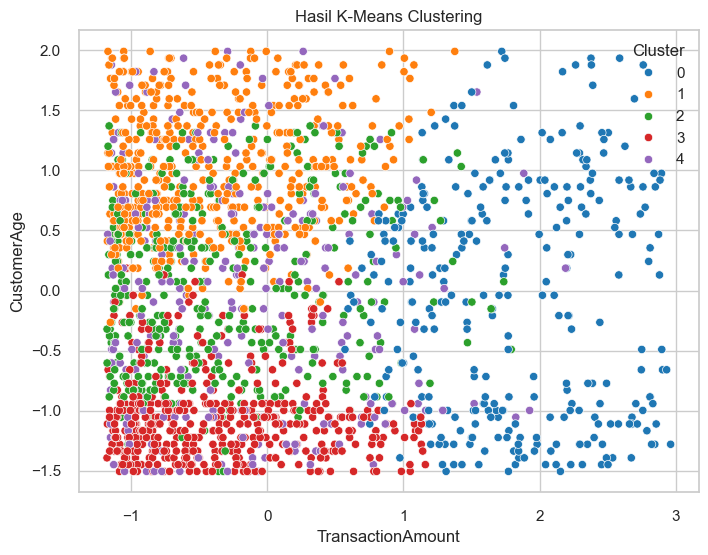

In [24]:
# Membuat visualisasi hasil clustering
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], hue=cluster_labels, palette="tab10")
plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title("Hasil K-Means Clustering")
plt.legend(title="Cluster")
plt.show()

### Penilaian (Opsional) - Skilled 2 (PCA)

In [25]:
# Membangun model menggunakan PCA.
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.33446199 0.25048409]


/Users/muhammadazrifatihahsusanto/Documents/Codingan/Dicoding/machine_learning/BMLP_Muhammad_Azri_Fatih_Susanto/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/muhammadazrifatihahsusanto/Documents/Codingan/Dicoding/machine_learning/BMLP_Muhammad_Azri_Fatih_Susanto/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/muhammadazrifatihahsusanto/Documents/Codingan/Dicoding/machine_learning/BMLP_Muhammad_Azri_Fatih_Susanto/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


In [26]:
# Simpan model PCA sebagai perbandingan dengan menjalankan cell code ini
joblib.dump(pca, "PCA_model_clustering.h5")

['PCA_model_clustering.h5']

## 6. Interpretasi Model / Analisis Setiap Cluster

**Metode yang digunakan:** analisis deskriptif (mean, min, max) per cluster pada fitur numerik.

**Alasan penggunaan:** untuk memahami karakteristik tiap cluster secara kuantitatif sebelum diberi label bermakna.

**Hasil yang didapat:** *(isi interpretasi Anda di sini setelah melihat output di bawah, misalnya cluster mana yang cenderung bertransaksi besar, cluster mana yang berisiko, dsb.)*

In [27]:
# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik.
df["Target"] = cluster_labels
df.groupby("Target")[num_cols].agg(["mean", "min", "max"])

TransactionAmount                 CustomerAge              \
                    mean     min     max        mean   min   max   
Target                                                             
0             650.207176  381.52  903.19   43.312292  18.0  80.0   
1             170.666998    0.84  557.41   62.626243  40.0  80.0   
2             186.890434    0.32  647.85   45.242347  18.0  69.0   
3             180.287368    0.26  510.24   26.098947  18.0  48.0   
4             215.675328    1.41  734.86   44.737226  18.0  80.0   

       TransactionDuration               LoginAttempts            \
                      mean    min    max          mean  min  max   
Target                                                             
0               110.624585   10.0  288.0           1.0  1.0  1.0   
1                93.548708   10.0  213.0           1.0  1.0  1.0   
2                98.535714   10.0  225.0           1.0  1.0  1.0   
3                99.012632   10.0  220.0           1.0  1.0  1.0   
4               240.448905  152.0  300.0           1.0  1.0  1.0   

       AccountBalance                     
                 mean      min       max  
Target                                    
0         4617.393223   102.20  14935.50  
1         4577.058907   120.89   9073.17  
2        10325.986658  5677.52  14977.99  
3         1598.294105   105.01   7047.04  
4         5189.805511   135.96  14348.65

In [28]:
# Pastikan nama kolom clustering sudah diubah menjadi Target
df.columns.tolist()

['TransactionAmount',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance',
 'TransactionAmount_bin',
 'Target']

In [29]:
# Simpan Data
df.to_csv("data_clustering.csv", index=False)

## 7. Inverse Transform Data (Opsional)

In [30]:
# inverse dataset ke rentang normal untuk numerikal
df_inverse = df.copy()
df_inverse[num_cols] = scaler.inverse_transform(df_scaled[num_cols])

In [31]:
# inverse dataset yang sudah diencode ke kategori aslinya.
for col, le in encoders.items():
    df_inverse[col] = le.inverse_transform(df[col])

In [32]:
# Lakukan analisis deskriptif minimal mean, min dan max untuk fitur numerik dan mode untuk
# kategorikal seperti pada basic tetapi menggunakan data yang sudah diinverse.
display(df_inverse.groupby("Target")[num_cols].agg(["mean", "min", "max"]))
display(df_inverse.groupby("Target")[list(encoders.keys())].agg(lambda x: x.mode().iloc[0]))

TransactionAmount                 CustomerAge              \
                    mean     min     max        mean   min   max   
Target                                                             
0             650.207176  381.52  903.19   43.312292  18.0  80.0   
1             170.666998    0.84  557.41   62.626243  40.0  80.0   
2             186.890434    0.32  647.85   45.242347  18.0  69.0   
3             180.287368    0.26  510.24   26.098947  18.0  48.0   
4             215.675328    1.41  734.86   44.737226  18.0  80.0   

       TransactionDuration               LoginAttempts            \
                      mean    min    max          mean  min  max   
Target                                                             
0               110.624585   10.0  288.0           1.0  1.0  1.0   
1                93.548708   10.0  213.0           1.0  1.0  1.0   
2                98.535714   10.0  225.0           1.0  1.0  1.0   
3                99.012632   10.0  220.0           1.0  1.0  1.0   
4               240.448905  152.0  300.0           1.0  1.0  1.0   

       AccountBalance                     
                 mean      min       max  
Target                                    
0         4617.393223   102.20  14935.50  
1         4577.058907   120.89   9073.17  
2        10325.986658  5677.52  14977.99  
3         1598.294105   105.01   7047.04  
4         5189.805511   135.96  14348.65

,TransactionType,Location,Channel,CustomerOccupation
Target,,,,
0,Debit,Mesa,ATM,Student
1,Debit,Charlotte,ATM,Retired
2,Debit,Fort Worth,Branch,Doctor
3,Debit,San Antonio,Branch,Student
4,Debit,Fresno,Branch,Engineer


In [33]:
# Periksa kembali data yang telah di-inverse.
df_inverse.head()

,TransactionAmount,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionAmount_bin,Target
0,14.09,Debit,San Diego,ATM,70.0,Doctor,81.0,1.0,5112.21,Rendah,1
1,376.24,Debit,Houston,ATM,68.0,Doctor,141.0,1.0,13758.91,Sangat Tinggi,2
2,126.29,Debit,Mesa,Online,19.0,Student,56.0,1.0,1122.35,Sedang,3
3,184.50,Debit,Raleigh,Online,26.0,Student,25.0,1.0,8569.06,Sedang,2
4,92.15,Debit,Oklahoma City,ATM,18.0,Student,172.0,1.0,781.68,Sedang,3


In [34]:
# Simpan Data Inverse
df_inverse.to_csv("data_clustering_inverse.csv", index=False)